In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

In [2]:
# Read preprocessed data
d_train = pd.read_csv("MCD_train_data.csv")
d_validation = pd.read_csv("MCD_validation_data.csv")

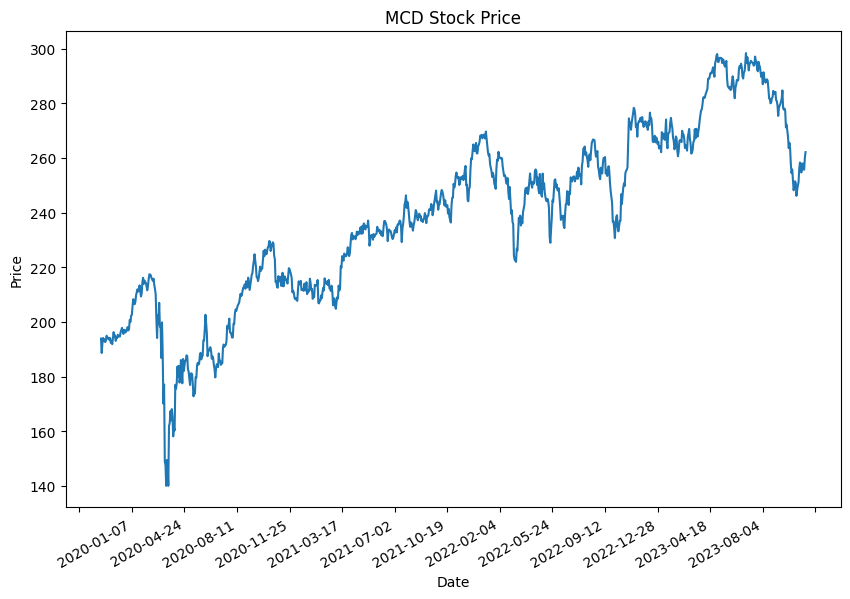

In [3]:
#visualise training data
d_train.index = pd.to_datetime(d_train.index)

plt.figure(figsize=(10,7))
plt.plot(d_train["Date"], d_train["Close"])
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=75))
plt.gcf().autofmt_xdate()
plt.xlabel("Date")
plt.title("MCD Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [4]:
#set up train and validation variable
X_train = d_train[["High", "Low", "Open", "Volume"]]
y_train = d_train["Close"]
X_val= d_validation[["High", "Low", "Open", "Volume"]]
y_val = d_validation["Close"]

#scaling
scaling_X = MinMaxScaler()
X_train_scaled = scaling_X.fit_transform(X_train)
X_val_scaled = scaling_X.transform(X_val)
print(X_train_scaled.shape, X_val_scaled.shape)
print(y_train.shape, y_val.shape)

(1006, 4) (126, 4)
(1006,) (126,)


In [5]:
#build model and save it
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
joblib.dump(linear, "Saved_Linear_Model.pkl")

['Saved_Linear_Model.pkl']

In [6]:
#predict the price using model
y_pred = linear.predict(X_val_scaled)

pva = pd.DataFrame(y_val.values, columns=["Actual"], index=d_validation["Date"][:])
pva["Predicted"] = y_pred
pva.index = pd.to_datetime(pva.index)
pva.index.name = "Date"
pva

,Actual,Predicted
Date,,
2023-11-01,261.970001,260.905005
2023-11-02,266.850006,266.523668
2023-11-03,267.869995,266.820017
2023-11-06,268.910004,268.385802
2023-11-07,268.670013,269.092496
...,...,...
2024-04-26,273.089996,274.315926
2024-04-29,273.549988,273.422249
2024-04-30,273.040009,272.497406


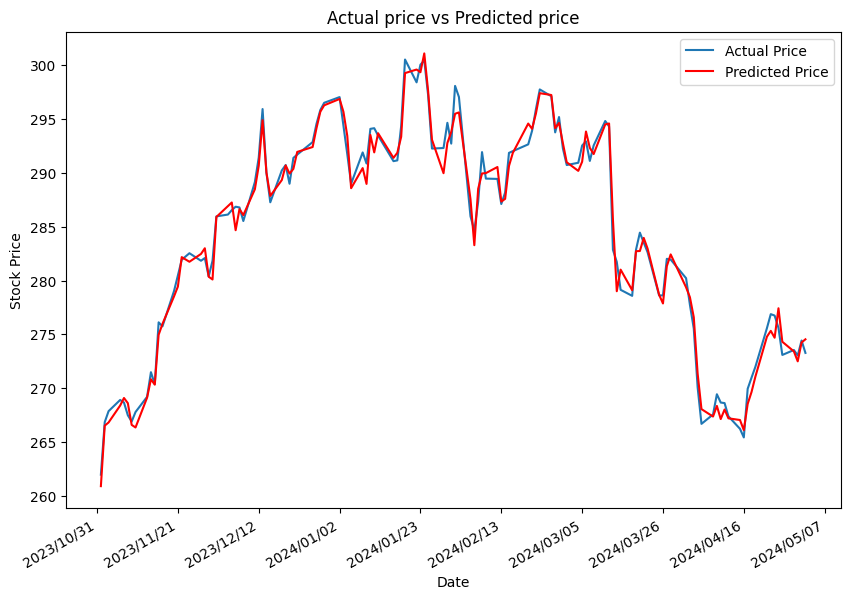

In [7]:
#Visualize the predicted price
plt.figure(figsize=(10,7))
plt.plot(pva.index, pva["Actual"], label="Actual Price")
plt.plot(pva.index, pva["Predicted"], label="Predicted Price", color="red")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=21))
plt.gcf().autofmt_xdate()
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Actual price vs Predicted price")
plt.legend()
plt.show()

In [8]:
# Performance metrics [Linear Regression]
MSE = mean_squared_error(y_val, y_pred)
MAE = mean_absolute_error(y_val, y_pred)
r_square = r2_score(y_val, y_pred)
print(f"Mean Square Error = {MSE}")
print(f"Mean Absolute Error = {MAE}")
print(f"R-squared value = {r_square}")

Mean Square Error = 1.1464057789122308
Mean Absolute Error = 0.8651410543734867
R-squared value = 0.9886651677384005
